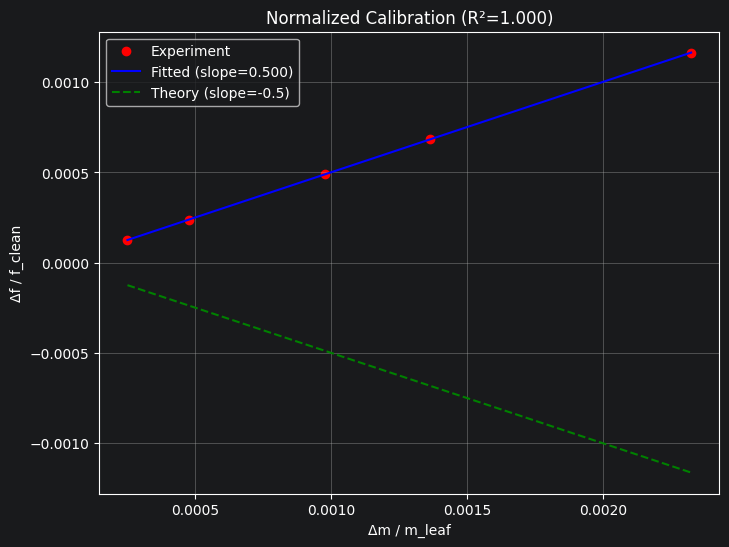

=== LeafTEOM Pilot 분석 ===
깨끗한 잎 진동수: 1.0853 Hz
PM 부착 후 진동수: 1.0853 Hz
진동수 변화: 0.0000 Hz
잎 무게: 2000 mg
캘리브레이션 slope: 0.5000
예측 PM 무게: 0.0000 mg


In [1]:


# from statistatics import compare_with_airkorea
from video_processing import extract_leaf_position
from fft_analysis import get_natural_frequency
from calibrataion_diff import run_calibration_analysis, get_pm_weight_normalized


def main():
    slope, _ = run_calibration_analysis()

    file_clean_path = 'test.mp4'
    cy_array_clean, fps, nan_per_clean = extract_leaf_position(file_clean_path)
    freq_clean, nan_per_fft_clean, snr_clean = get_natural_frequency(cy_array_clean, fps)

    file_pm_path = 'test_pm.mp4'
    cy_array_pm, fps, nan_per_pm = extract_leaf_position(file_pm_path)
    freq_pm, nan_fft_per_pm, snr_pm = get_natural_frequency(cy_array_pm, fps)

    m_leaf = 2000


    predicted_pm = get_pm_weight_normalized(freq_clean, freq_pm, m_leaf, slope)

    #final_score = compare_with_airkorea('experiment_data.csv')


    print("=== LeafTEOM Pilot 분석 ===")
    print(f"깨끗한 잎 진동수: {freq_clean:.4f} Hz")
    print(f"PM 부착 후 진동수: {freq_pm:.4f} Hz")
    print(f"진동수 변화: {freq_clean - freq_pm:.4f} Hz")
    print(f"잎 무게: {m_leaf} mg")
    print(f"캘리브레이션 slope: {slope:.4f}")
    print(f"예측 PM 무게: {predicted_pm:.4f} mg")

if __name__ == "__main__":
    main()


In [2]:
import pandas as pd
import numpy as np

# 가짜 데이터 (이론값 slope = -0.5 확인용)
data = {
    'm_leaf': [2000, 2100, 2050, 2200, 2150],
    'PM_Weight': [0.5, 1.0, 2.0, 3.0, 5.0],
    'Freq_Clean_1': [5.0]*5,
    'Freq_Clean_2': [5.0]*5,
    'Freq_Clean_3': [5.0]*5,
}

# 이론대로 Δf 계산: Δf/f = -0.5 × Δm/m
# Δf = -0.5 × (PM/m_leaf) × f_clean
# f_pm = f_clean - Δf  (Δf 양수면 감소)
freq_clean = 5.0
freq_pm_list = []
for m, pm in zip(data['m_leaf'], data['PM_Weight']):
    delta_f = 0.5 * (pm / m) * freq_clean   # 이론 변화량
    f_pm = freq_clean - delta_f
    freq_pm_list.append(f_pm)

data['Freq_PM_1'] = freq_pm_list
data['Freq_PM_2'] = freq_pm_list
data['Freq_PM_3'] = freq_pm_list

df = pd.DataFrame(data)
df.to_csv('experiment_data.csv', index=False)
print(df)

   m_leaf  PM_Weight  Freq_Clean_1  Freq_Clean_2  Freq_Clean_3  Freq_PM_1  \
0    2000        0.5           5.0           5.0           5.0   4.999375   
1    2100        1.0           5.0           5.0           5.0   4.998810   
2    2050        2.0           5.0           5.0           5.0   4.997561   
3    2200        3.0           5.0           5.0           5.0   4.996591   
4    2150        5.0           5.0           5.0           5.0   4.994186   

   Freq_PM_2  Freq_PM_3  
0   4.999375   4.999375  
1   4.998810   4.998810  
2   4.997561   4.997561  
3   4.996591   4.996591  
4   4.994186   4.994186  
